# 1.RFM Classification

In [ ]:
import pandas as pd

BASE_DATA = "data/"
START_DATE = '2012-01-01'
# 1. Đọc dữ liệu
orders = pd.read_csv(BASE_DATA+'orders.csv', parse_dates=['order_date'])
payments = pd.read_csv(BASE_DATA+'payments.csv')
returns = pd.read_csv(BASE_DATA+'returns.csv')
geography = pd.read_csv(BASE_DATA+'geography.csv')
orders = orders[orders['order_date'] >= START_DATE]
order_items = pd.read_csv(BASE_DATA+'order_items.csv')
customers = pd.read_csv(BASE_DATA+'customers.csv')
valid_order_ids = orders['order_id'].unique()
payments = payments[payments['order_id'].isin(valid_order_ids)]
returns = returns[returns['order_id'].isin(valid_order_ids)]


/var/folders/yf/z8cyz0qn4r557bdjflrksgkw0000gn/T/ipykernel_45844/3429244116.py:11: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(BASE_DATA+'order_items.csv')


In [ ]:

# 1. Định nghĩa ngày tham chiếu (Ngày cuối cùng trong dữ liệu + 1 ngày)
ref_date = pd.to_datetime('2023-01-01')

# 2. Merge dữ liệu đơn hàng với giá trị thanh toán
rfm = orders.merge(payments[['order_id', 'payment_value']], on='order_id', how='left')

# 3. Lọc bỏ các đơn hàng đã bị hủy
rfm = rfm[rfm['order_status'] != 'cancelled']

# 4. Gom nhóm theo khách hàng và tính toán các chỉ số cơ bản
rfm_agg = rfm.groupby('customer_id').agg(
    last_order_date = ('order_date', 'max'),
    first_order_date = ('order_date', 'min'),
    frequency = ('order_id', 'nunique'),
    monetary = ('payment_value', 'sum'),
    avg_order_value = ('payment_value', 'mean')
).reset_index()

# 5. Tính toán số ngày Recency (độ mới) và Tenure (thâm niên)
rfm_agg['recency_days'] = (ref_date - rfm_agg['last_order_date']).dt.days
rfm_agg['tenure_days'] = (ref_date - rfm_agg['first_order_date']).dt.days

# 6. Tính điểm R, F, M (Scoring) theo phương pháp chia 5 phần bằng nhau (qcut)
# Điểm R: Ngày mua gần nhất càng nhỏ thì điểm càng cao (5 là tốt nhất)
rfm_agg['R_score'] = pd.qcut(rfm_agg['recency_days'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Điểm F: Tần suất mua càng cao điểm càng cao. Dùng rank(method='first') để xử lý dữ liệu trùng lặp
rfm_agg['F_score'] = pd.qcut(rfm_agg['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Điểm M: Tổng giá trị mua hàng càng cao điểm càng cao
rfm_agg['M_score'] = pd.qcut(rfm_agg['monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# 7. Tạo điểm RFM tổng hợp (Ví dụ: tổ hợp 3 chữ số R-F-M)
rfm_agg['RFM_score'] = rfm_agg['R_score'] * 100 + rfm_agg['F_score'] * 10 + rfm_agg['M_score']

In [ ]:
def rfm_segment(row):
    # 1. Trích xuất các giá trị điểm số từ hàng
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    
    # 2. Phân loại theo điều kiện (Thứ tự ưu tiên từ cao xuống thấp)
    if r >= 4 and f >= 4:
        return 'Champions'
    
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    
    elif r >= 4 and f <= 2:
        return 'New Customers'
    
    elif r >= 3 and f >= 1:
        return 'Potential Loyalists'
    
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cant Lose Them'
    
    elif r <= 2 and f >= 3:
        return 'At Risk'
    
    elif r <= 2 and f <= 2:
        return 'Lost'
    
    elif r == 3 and f <= 2:
        return 'About To Sleep'
    
    else:
        return 'Need Attention'

# 3. Áp dụng hàm cho toàn bộ tập dữ liệu
rfm_agg['rfm_segment'] = rfm_agg.apply(rfm_segment, axis=1)

In [ ]:
# 1. Merge thông tin khách hàng với dữ liệu RFM
dim_cust = customers.merge(rfm_agg, on='customer_id', how='left')

# 2. Merge thêm thông tin địa lý dựa trên mã zip (loại bỏ trùng lặp mã zip trước khi merge)
dim_cust = dim_cust.merge(
    geography[['zip', 'region']].drop_duplicates(subset='zip'),
    on='zip', 
    how='left'
)

# 3. Xử lý các giá trị thiếu (NaN) cho những khách hàng chưa từng mua hàng
dim_cust['frequency'] = dim_cust['frequency'].fillna(0).astype(int)
dim_cust['monetary'] = dim_cust['monetary'].fillna(0)
dim_cust['rfm_segment'] = dim_cust['rfm_segment'].fillna('Never Purchased')

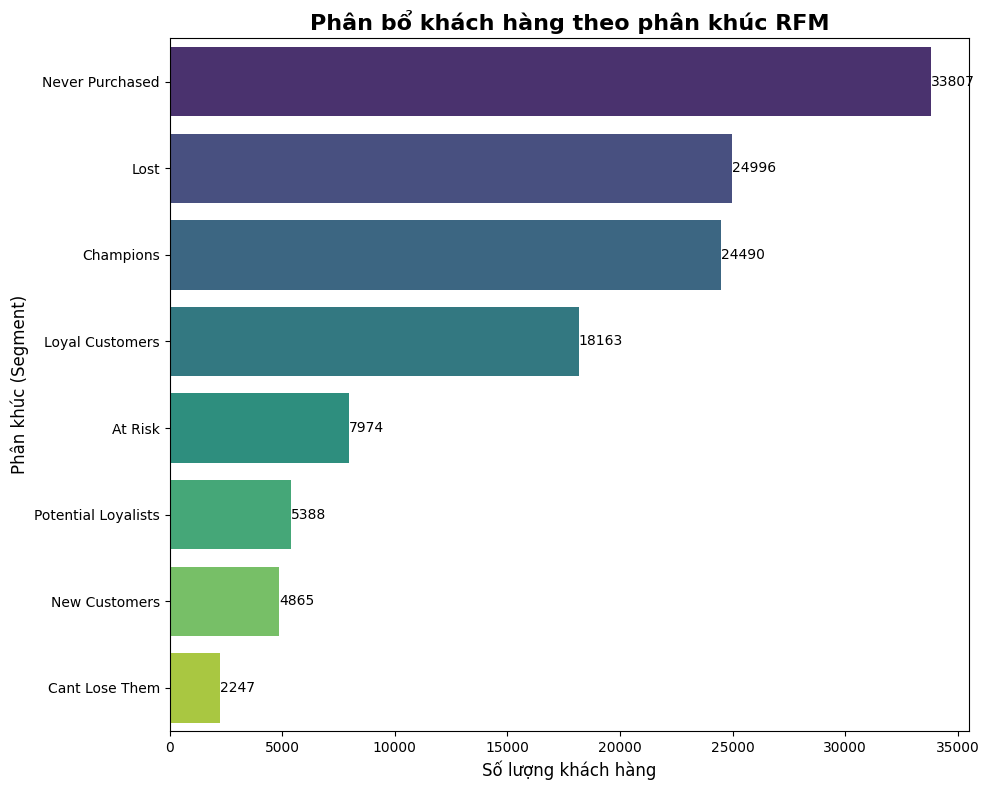

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
#1. Tính toán số lượng khách hàng trong mỗi phân khúc và sắp xếp giảm dần
segment_counts = dim_cust['rfm_segment'].value_counts().reset_index()
segment_counts.columns = ['rfm_segment', 'count']

# 2. Vẽ biểu đồ thanh ngang
plt.figure(figsize=(10, 8)) # Thiết lập kích thước khung hình

sns.barplot(
    data=segment_counts, 
    y='rfm_segment', 
    x='count', 
    palette='viridis', 
    hue='rfm_segment',
    legend=False
)

# 3. Thêm tiêu đề và nhãn
plt.title('Phân bổ khách hàng theo phân khúc RFM', fontsize=16, fontweight='bold')
plt.xlabel('Số lượng khách hàng', fontsize=12)
plt.ylabel('Phân khúc (Segment)', fontsize=12)

# 4. Hiển thị giá trị số lượng trên từng thanh (tùy chọn)
for i, count in enumerate(segment_counts['count']):
    plt.text(count + 0.5, i, str(int(count)), va='center', fontsize=10)

plt.tight_layout()
plt.show()

# 2.Customer Segment Profile

<Figure size 1500x600 with 0 Axes>

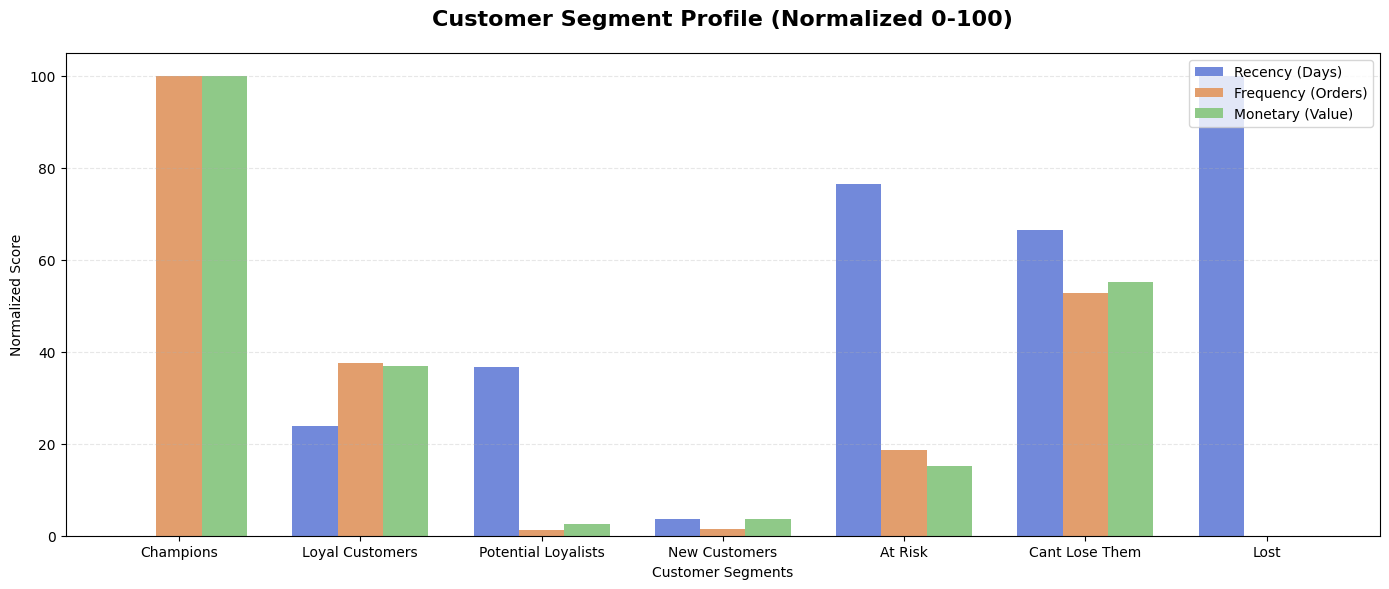

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tiền xử lý dữ liệu (Nếu chưa có)
metrics = ['recency_days', 'frequency', 'monetary']
target_segments = ['Champions', 'Loyal Customers', 'Potential Loyalists', 
                   'New Customers', 'At Risk', 'Cant Lose Them', 'Lost']

# Loại bỏ 'Never Purchased' vì nhóm này thường không có dữ liệu giao dịch
df_profile = df[df['rfm_segment'].isin(target_segments)]

# 2. Tính giá trị trung bình cho từng segment
profile_data = df_profile.groupby('rfm_segment')[metrics].mean()

# 3. Chuẩn hóa về thang điểm 0-100 để so sánh trực quan
# Công thức: (x - min) / (max - min) * 100
profile_norm = (profile_data - profile_data.min()) / (profile_data.max() - profile_data.min()) * 100

# 4. Vẽ biểu đồ
plt.figure(figsize=(15, 6))
ax = profile_norm.reindex(target_segments).plot(
    kind='bar', 
    figsize=(14, 6), 
    width=0.75, 
    color=['#7289da', '#e29e6d', '#8fc988'] # Màu sắc tương ứng Recency, Frequency, Monetary
)

plt.title('Customer Segment Profile (Normalized 0-100)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Normalized Score')
plt.xlabel('Customer Segments')
plt.xticks(rotation=0)
plt.legend(['Recency (Days)', 'Frequency (Orders)', 'Monetary (Value)'], loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 3.Segment Matrix

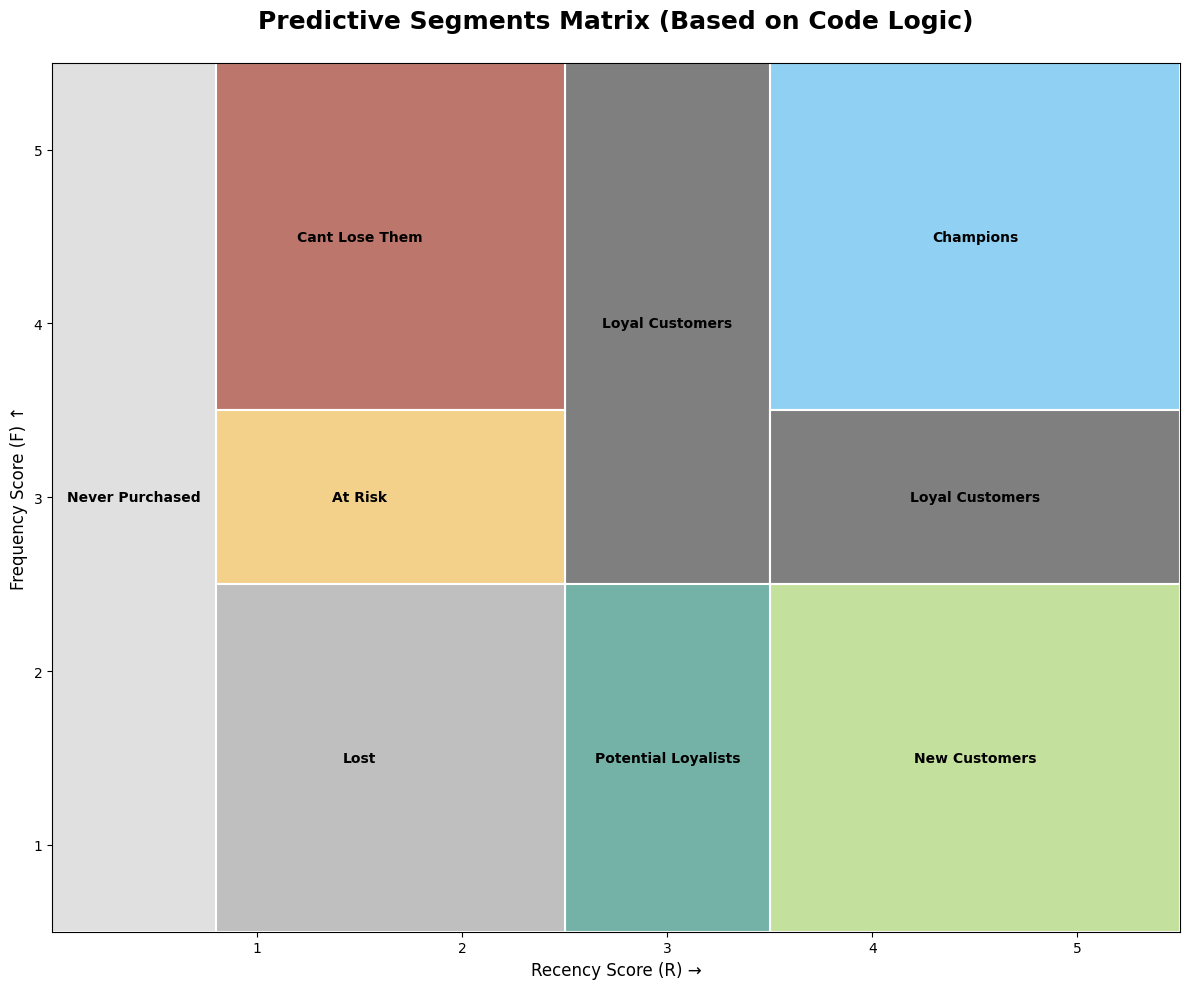

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 10))

# Cập nhật segments_rects khớp theo logic hàm rfm_segment (Thang điểm 1-5)
# Tọa độ: (x, y, width, height, label, color)
# x tương ứng R_score (0-4), y tương ứng F_score (0-4)
segments_rects = [
    # 1. Champions: r >= 4 & f >= 4
    (3, 3, 2, 2, "Champions", '#90d1f3'),
    
    # 2. Loyal Customers: r >= 3 & f >= 3 (Trừ Champions)
    # Bao gồm các ô (R:3, F:3-5) và (R:4-5, F:3)
    (2, 2, 1, 3, "Loyal Customers", '#7f7f7f'), # Cột R=3
    (3, 2, 2, 1, "Loyal Customers", '#7f7f7f'), # Hàng F=3 (phần R=4,5)
    
    # 3. New Customers: r >= 4 & f <= 2
    (3, 0, 2, 2, "New Customers", '#c4e09d'),
    
    # 4. Potential Loyalists: r >= 3 & f >= 1 (Phần còn lại của R>=3)
    # Thực tế sẽ nhận ô (R:3, F:1-2)
    (2, 0, 1, 2, "Potential Loyalists", '#74b2a8'),
    
    # 5. Cant Lose Them: r <= 2 & f >= 4 (M >= 4)
    # Vì Map chỉ có 2 trục R-F, ta vẽ nhóm này ở vùng F cao nhất của R thấp
    (0, 3, 2, 2, "Cant Lose Them", '#bc766c'),
    
    # 6. At Risk: r <= 2 & f >= 3
    # Thực tế sẽ nhận ô (R:1-2, F:3)
    (0, 2, 2, 1, "At Risk", '#f4d18a'),
    
    # 7. Lost: r <= 2 & f <= 2
    (0, 0, 2, 2, "Lost", '#bfbfbf'),
    
    # Nhóm Never Purchased (Nằm ngoài hệ thống điểm 1-5)
    (-0.5, 0, 0.8, 5, "Never Purchased", '#e0e0e0'),
]

for x, y, w, h, label, color in segments_rects:
    rect = patches.Rectangle((x, y), w, h, facecolor=color, edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    
    # Tránh ghi đè text nếu một segment chia làm 2 khối (như Loyal)
    # Chỉ ghi text ở khối chính hoặc dùng logic check
    ax.text(x + w/2, y + h/2, label, ha='center', va='center', 
            fontsize=10, fontweight='bold', color='black', wrap=True)

# Cấu hình trục
ax.set_xlim(-0.5, 5)
ax.set_ylim(0, 5)

# Đặt nhãn trục theo điểm số 1-5
ax.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5])
ax.set_xticklabels(['1', '2', '3', '4', '5'])
ax.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])
ax.set_yticklabels(['1', '2', '3', '4', '5'])

plt.title('Predictive Segments Matrix (Based on Code Logic)', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Recency Score (R) →', fontsize=12)
plt.ylabel('Frequency Score (F) ↑', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Giả sử đã có 2 DataFrame: returns và order_items
# Kết hợp 2 bảng dựa trên order_id và product_id
df_merged = returns.merge(order_items[['order_id', 'product_id', 'unit_price', 'quantity']], 
                          on=['order_id', 'product_id'], 
                          how='left')

# 2. Tính giá trị gốc của lượng hàng bị trả (Original Value)
# Lưu ý: quantity ở đây nên là return_quantity từ bảng returns
df_merged['original_value'] = df_merged['unit_price'] * df_merged['return_quantity']

# 3. Gom nhóm theo lý do trả hàng (Lỗi doanh nghiệp)
analysis = df_merged.groupby('return_reason').agg({
    'original_value': 'sum',
    'refund_amount': 'sum'
}).reset_index()

# Tính tỷ lệ thất thoát của khách hàng (%)
analysis['loss_percentage'] = ((analysis['original_value'] - analysis['refund_amount']) / analysis['original_value'] * 100).round(2)

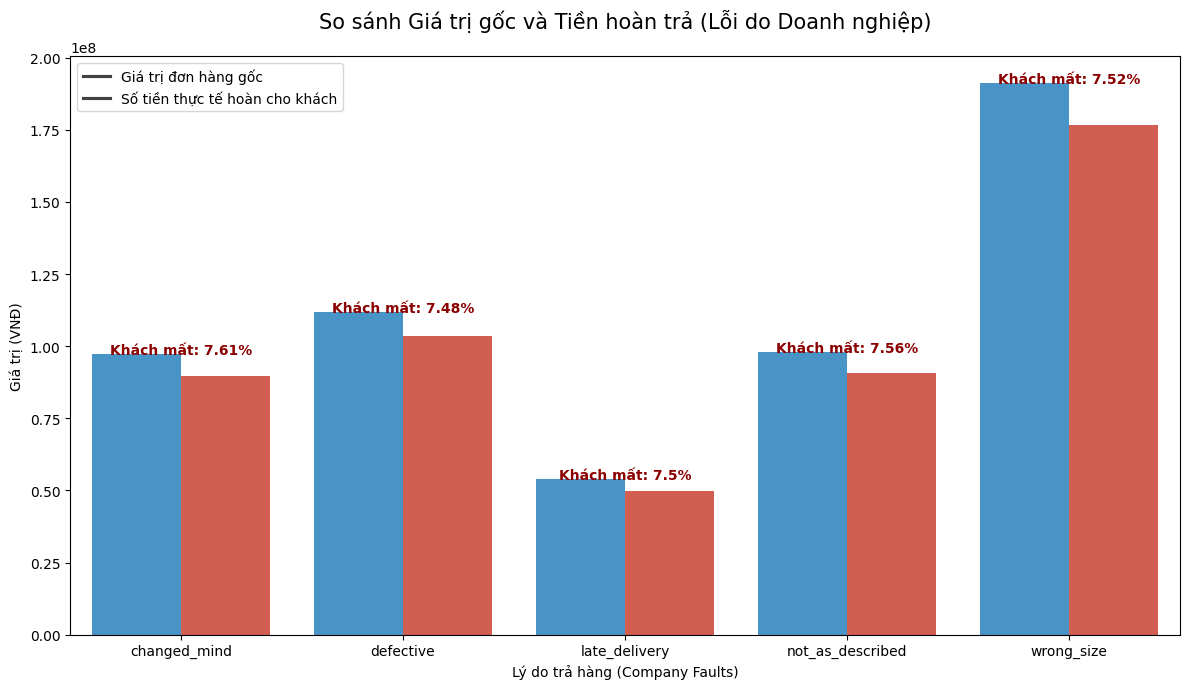

In [ ]:
# Chuyển dữ liệu sang dạng long-format để vẽ với Seaborn
plot_data = analysis.melt(id_vars='return_reason', 
                          value_vars=['original_value', 'refund_amount'],
                          var_name='Type', value_name='Amount')

plt.figure(figsize=(12, 7))

# Vẽ biểu đồ cột đôi
sns.barplot(data=plot_data, x='return_reason', y='Amount', hue='Type', palette=['#3498db', '#e74c3c'])

# Thêm nhãn tỷ lệ % không được hoàn lên đầu cột
for i, reason in enumerate(analysis['return_reason']):
    loss = analysis.loc[i, 'loss_percentage']
    plt.text(i, analysis.loc[i, 'original_value'] + 5, f'Khách mất: {loss}%', 
             ha='center', color='darkred', fontweight='bold')

plt.title('So sánh Giá trị gốc và Tiền hoàn trả (Lỗi do Doanh nghiệp)', fontsize=15, pad=20)
plt.ylabel('Giá trị (VNĐ)')
plt.xlabel('Lý do trả hàng (Company Faults)')
plt.legend(['Giá trị đơn hàng gốc', 'Số tiền thực tế hoàn cho khách'])

plt.tight_layout()
plt.show()

# 4.Cohort Retention Heatmap

In [ ]:
import pandas as pd
import numpy as np

# 1. Xác định cohort (loại bỏ đơn hủy)
first_order = orders[orders['order_status'] != 'cancelled'].copy()
first_order = first_order.groupby('customer_id')['order_date'].min().reset_index()
first_order.columns = ['customer_id', 'cohort_date']
first_order['cohort_month'] = first_order['cohort_date'].dt.to_period('M')

# 2. Tính period_number
orders_cohort = orders[orders['order_status'] != 'cancelled'][['order_id', 'customer_id', 'order_date']].copy()
orders_cohort['order_month'] = orders_cohort['order_date'].dt.to_period('M')
orders_cohort = orders_cohort.merge(first_order[['customer_id', 'cohort_month']], on='customer_id')

orders_cohort['period_number'] = (
    (orders_cohort['order_month'].dt.year - orders_cohort['cohort_month'].dt.year) * 12 +
    (orders_cohort['order_month'].dt.month - orders_cohort['cohort_month'].dt.month)
)

# 3. Tính Retention Rate (%)
cohort_sizes = orders_cohort.groupby('cohort_month')['customer_id'].nunique().reset_index()
cohort_sizes.columns = ['cohort_month', 'cohort_size']

retention = orders_cohort.groupby(['cohort_month', 'period_number'])['customer_id'].nunique().reset_index()
retention.columns = ['cohort_month', 'period_number', 'active_customers']

retention = retention.merge(cohort_sizes, on='cohort_month')
retention['retention_rate'] = (retention['active_customers'] / retention['cohort_size'] * 100).round(2)

# Tạo ma trận Pivot
retention_matrix = retention.pivot(index='cohort_month', columns='period_number', values='retention_rate')

# --- BƯỚC LỌC THEO YÊU CẦU: Lấy từ 2013 đến hết 2014 ---
# Sử dụng .loc để chọn khoảng thời gian từ Index
retention_matrix = retention_matrix.loc['2013-01':]

# Chỉ lấy 24 tháng theo dõi (Period 0 đến 24)
retention_matrix = retention_matrix.iloc[::12, :25]

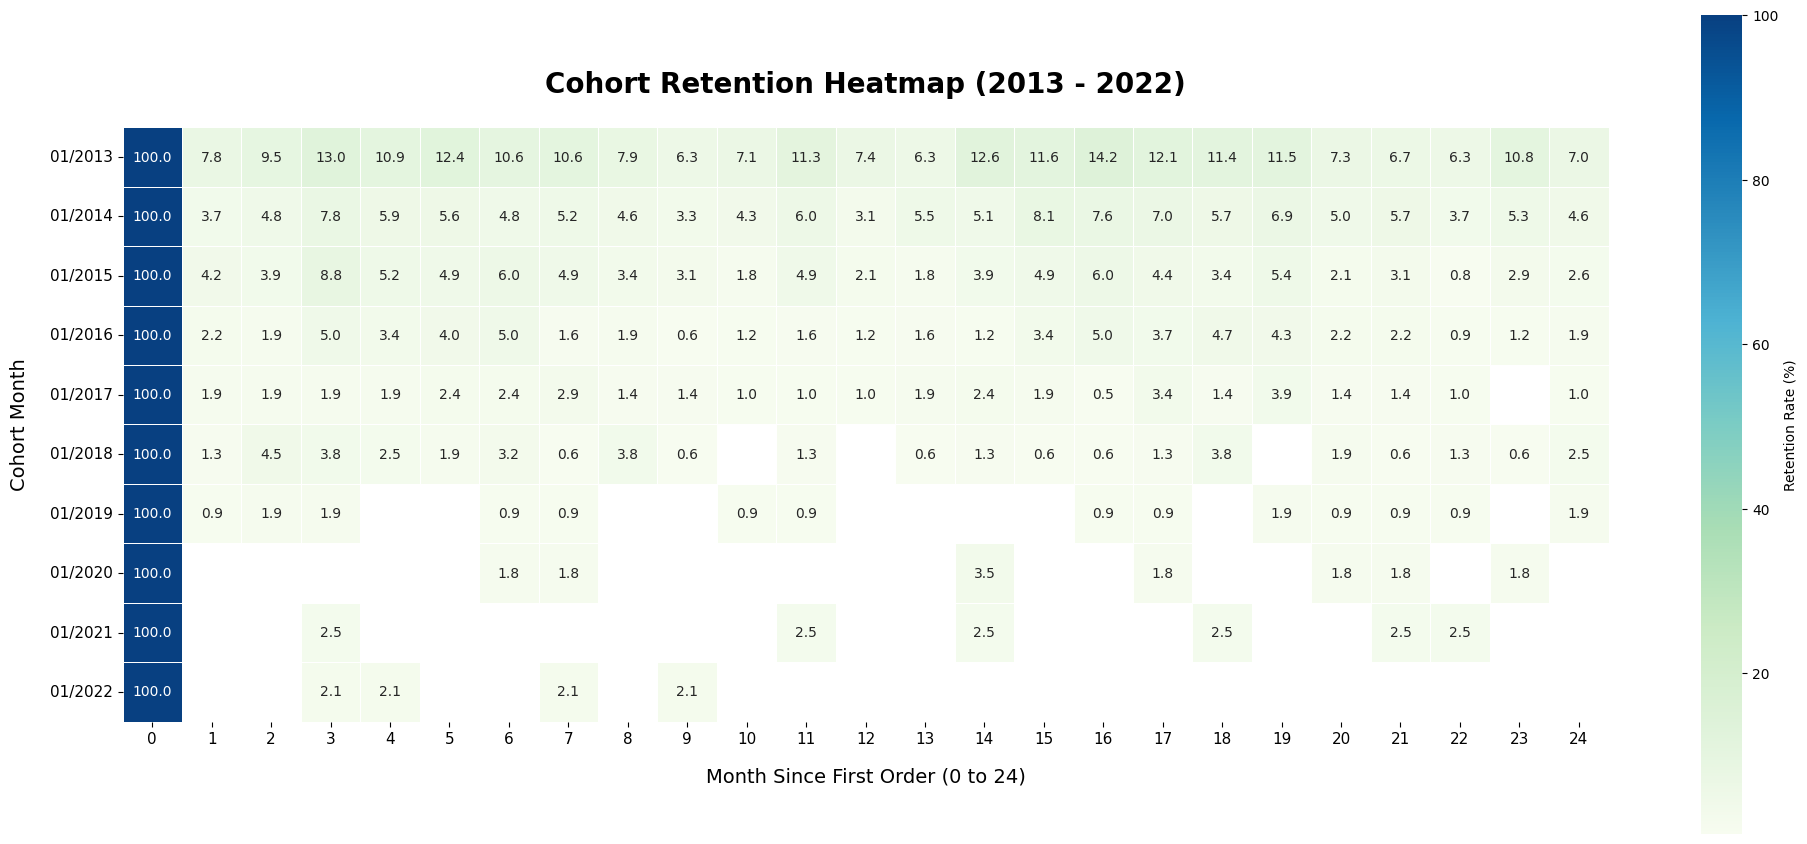

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Kích thước 20x12 là lý tưởng cho 24 dòng (2 năm)
plt.figure(figsize=(20, 12)) 

plt.title('Cohort Retention Heatmap (2013 - 2022)', fontsize=20, fontweight='bold', pad=25)

# Vẽ heatmap mô phỏng Tableau
sns.heatmap(data=retention_matrix, 
            annot=True, 
            fmt='.1f', 
            cmap='GnBu',         # Dải màu Navy/Teal
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": 0.7, 'label': 'Retention Rate (%)'},
            annot_kws={"size": 10})

plt.xlabel('Month Since First Order (0 to 24)', fontsize=14, labelpad=15)
plt.ylabel('Cohort Month', fontsize=14, labelpad=15)

# Định dạng nhãn trục Y thành MM/YYYY
y_labels = [month.strftime('%m/%Y') for month in retention_matrix.index]
plt.yticks(ticks=np.arange(len(y_labels)) + 0.5, labels=y_labels, fontsize=11, rotation=0)
plt.xticks(fontsize=11)

plt.tight_layout()
plt.show()

# 5. Statiscal Value 

In [ ]:
df = dim_cust.copy()

In [ ]:
import pandas as pd

# 1. [Total Customers] - COUNTD([customer_id])
total_customers = df['customer_id'].nunique()

# 2. [Active Customers] - Champions, Loyal Customers, New Customers, Potential Loyalists
active_segments = ["Champions", "Loyal Customers", "New Customers", "Potential Loyalists", 'Cant Lose Them']
active_customers = df[df['rfm_segment'].isin(active_segments)].shape[0]

# 3. [Churn Rate %] - (Lost, At Risk) / Total Customers
churn_segments = ["Lost", "At Risk"]
churn_count = df[df['rfm_segment'].isin(churn_segments)].shape[0]
churn_rate_pct = (churn_count / total_customers) * 100

# 4. [Avg LTV] - Trung bình monetary loại trừ "Never Purchased"
# Dùng .mean() trên tập dữ liệu đã lọc (tương đương AVG(IIF...))
avg_ltv = df[df['rfm_segment'] != "Never Purchased"]['monetary'].mean()

In [ ]:
print(f"{' KPI DASHBOARD SUMMARY ':=^45}")
print(f"Total Customers (Distinct) : {total_customers:,}")
print(f"Active Customers           : {active_customers:,}")
print(f"Churn Rate (%)             : {churn_rate_pct:.2f}%")
print(f"Avg LTV (Paid Customers)   : {avg_ltv:,.2f}")
print(f"{'=' * 45}")

# Kiểm tra phân bổ khách hàng Active vs Churn
print("\n[Chi tiết phân bổ nhóm]")
print(df['rfm_segment'].value_counts())

=========== KPI DASHBOARD SUMMARY ===========
Total Customers (Distinct) : 121,930
Active Customers           : 55,153
Churn Rate (%)             : 27.04%
Avg LTV (Paid Customers)   : 161,522.59

[Chi tiết phân bổ nhóm]
rfm_segment
Never Purchased        33807
Lost                   24996
Champions              24490
Loyal Customers        18163
At Risk                 7974
Potential Loyalists     5388
New Customers           4865
Cant Lose Them          2247
Name: count, dtype: int64


In [ ]:
cs_users = orders[(orders['order_date'] >= '2012-01-01') & 
                  (orders['order_date'] < '2022-01-01')]['customer_id'].unique()
CS = len(cs_users)

first_purchase_dates = orders.groupby('customer_id')['order_date'].min()
new_customers_2022 = first_purchase_dates[(first_purchase_dates >= '2022-01-01') & 
                                          (first_purchase_dates <= '2022-12-31')]
CN = len(new_customers_2022)

ce_users = orders[(orders['order_date'] >= '2022-01-01') & 
                  (orders['order_date'] <= '2022-12-31')]['customer_id'].unique()
CE = len(ce_users)

# 4. Tính toán
retention_count = CE - CN
crr = (retention_count / CS) * 100 if CS > 0 else 0

print(f"Khách Active đầu kỳ: {CS}")
print(f"Khách Active cuối kỳ: {CE}")
print(f"Khách mới trong kỳ: {CN}")
print(f"Số khách cũ quay lại (Retained): {retention_count}")
print(f"--> CRR: {crr:.2f}%")

Khách Active đầu kỳ: 88924
Khách Active cuối kỳ: 24696
Khách mới trong kỳ: 1322
Số khách cũ quay lại (Retained): 23374
--> CRR: 26.29%


# 6. Aqquistion Channel ROI

In [ ]:
import pandas as pd
import numpy as np

# 1. Định nghĩa nhóm khách hàng "Chất lượng cao" (Active) theo Dashboard của bạn
active_segments = ["Champions", "Loyal Customers", "Potential Loyalists", "New Customers"]

# 2. Tổng hợp dữ liệu theo Kênh và RFM Segment
roi_rfm = df.groupby(['acquisition_channel', 'rfm_segment']).agg(
    customer_count=('customer_id', 'nunique'),
    total_revenue=('monetary', 'sum')
).reset_index()

# 3. Tính Avg LTV cho từng tổ hợp
roi_rfm['avg_ltv'] = roi_rfm['total_revenue'] / roi_rfm['customer_count']

# 4. Tính toán mức độ đóng góp của nhóm Active cho từng kênh
channel_summary = roi_rfm.groupby('acquisition_channel').agg(
    total_cust=('customer_count', 'sum'),
    total_rev=('total_revenue', 'sum')
).reset_index()

# Lọc riêng nhóm Active để tính ROI "chất lượng"
active_roi = roi_rfm[roi_rfm['rfm_segment'].isin(active_segments)].groupby('acquisition_channel').agg(
    active_cust=('customer_count', 'sum'),
    active_rev=('total_revenue', 'sum')
).reset_index()

# Kết hợp dữ liệu
final_roi = channel_summary.merge(active_roi, on='acquisition_channel')

# Chỉ số ROI Chất lượng: Tỷ lệ doanh thu từ nhóm Active trên tổng doanh thu kênh
final_roi['active_revenue_share'] = (final_roi['active_rev'] / final_roi['total_rev'] * 100).round(2)
# Avg LTV của riêng nhóm Active trong kênh đó
final_roi['active_avg_ltv'] = final_roi['active_rev'] / final_roi['active_cust']

print(final_roi.sort_values(by='active_revenue_share', ascending=False))

  acquisition_channel  total_cust     total_rev  active_cust    active_rev  \
3         paid_search       24285  2.830098e+09        10567  2.463480e+09   
1      email_campaign       14674  1.702679e+09         6361  1.482026e+09   
5        social_media       24448  2.865168e+09        10557  2.490777e+09   
2      organic_search       36450  4.283367e+09        15787  3.720238e+09   
0              direct        9803  1.137825e+09         4285  9.874482e+08   
4            referral       12270  1.414720e+09         5349  1.225432e+09   

   active_revenue_share  active_avg_ltv  
3                 87.05   233129.545909  
1                 87.04   232986.348541  
5                 86.93   235936.099288  
2                 86.85   235651.972987  
0                 86.78   230442.981701  
4                 86.62   229095.601256  


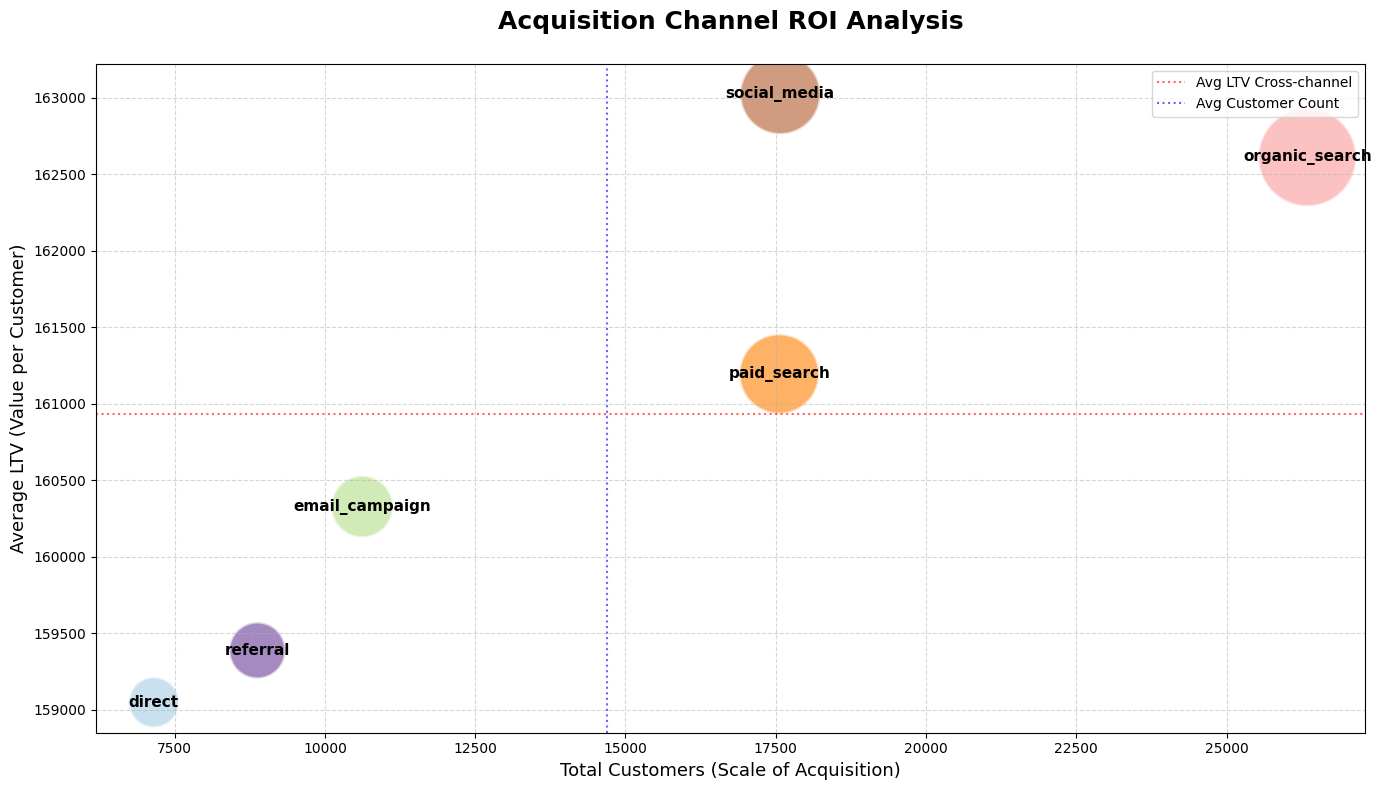

In [ ]:
plt.figure(figsize=(14, 8))

# Thiết lập các biến cho biểu đồ
x = channel_metrics['total_customers']
y = channel_metrics['avg_ltv']
size = channel_metrics['total_revenue'] / channel_metrics['total_revenue'].max() * 5000 # Scale kích thước bubble
channels = channel_metrics['acquisition_channel']

# Sử dụng bảng màu đa dạng
colors = plt.cm.Paired(np.linspace(0, 1, len(channels)))

# Vẽ Bubble Chart
scatter = plt.scatter(x, y, s=size, c=colors, alpha=0.6, edgecolors="white", linewidth=2)

# Thêm nhãn tên kênh cho từng bubble
for i, txt in enumerate(channels):
    plt.annotate(txt, (x[i], y[i]), fontsize=11, fontweight='bold', ha='center', va='center')

# Định dạng biểu đồ
plt.title('Acquisition Channel ROI Analysis', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Total Customers (Scale of Acquisition)', fontsize=13)
plt.ylabel('Average LTV (Value per Customer)', fontsize=13)

# Thêm lưới để dễ quan sát
plt.grid(True, linestyle='--', alpha=0.5)

# Thêm đường trung bình để phân loại các kênh
plt.axhline(y.mean(), color='red', linestyle=':', alpha=0.6, label='Avg LTV Cross-channel')
plt.axvline(x.mean(), color='blue', linestyle=':', alpha=0.6, label='Avg Customer Count')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()